# Market Sentiment Classification — Final Solution (Group 15)

This notebook is derived from `tm_tests_15.ipynb` and preserves the same data import, EDA, preprocessing, train/validation split and evaluation structure used in the experimental notebook.

The experimental notebook selected **Transformer: ProsusAI/finbert** as the best validation model. Therefore, this final notebook removes the alternative model training blocks and trains only the selected final model, then generates the official `pred_15.csv` file.

Labels: **0 = Bearish**, **1 = Bullish**, **2 = Neutral**.

# 1. Data Import

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import time

# --------- ISTO TEM QUE SAIR NO FINAL
#from main_lib_deep import (
#    clean_text, stem_simple, preprocess_lemma, preprocess_stem,
#    set_global_seed, evaluate_classification, print_classification_summary,
#    make_submission, LABEL_NAMES, LABEL_MAP, ID2LABEL, LABEL2ID
#)

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import os
import nltk
import torch
import transformers
import tensorflow


#### =>  auxiliar functions & constants

In [28]:
important_words = {
    "up", "down", "buy", "sell", "bull", "bear", "bullish", "bearish",
    "profit", "loss", "long", "short", "gain", "gains", "drop", "drops",
    "rally", "rallies", "rise", "rises", "fall", "falls", "low", "high",
    "beat", "miss", "upgrade", "downgrade"
}

stop_words = set(ENGLISH_STOP_WORDS) - important_words

def clean_text(text):
    """Clean a tweet using regular expressions."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)       # remove URLs
    text = re.sub(r"@\w+", " ", text)                            # remove mentions
    text = re.sub(r"#", "", text)                                 # keep hashtag words
    text = re.sub(r"\$([a-zA-Z]+)", r" \1 ", text)               # $AAPL -> AAPL
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                     # remove symbols/numbers
    text = re.sub(r"\s+", " ", text).strip()                     # remove extra spaces
    return text


# Stemming and Lemmatization
lemma = WordNetLemmatizer()
def stem_simple(word):
    """A small fallback stemmer so the notebook runs without extra downloads."""
    for suffix in ['ing','edly','ed','ly','ies','s']:
        if word.endswith(suffix) and len(word) > len(suffix)+3:
            if suffix == "ies":
                return word[:-3] + "y"
            return word[:-len(suffix)]
    return word

def preprocess_lemma(text):
    """Basic cleaning + stopword removal. Used as the main normalized text column."""
    cleaned = clean_text(text)
    tokens = [lemma.lemmatize(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)

def preprocess_stem(text):
    cleaned = clean_text(text)
    tokens = [stem_simple(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)


# =========================
# Deep Learning utilities
# =========================
# These helpers are intentionally optional: the classic sklearn pipeline still
# runs even when TensorFlow / PyTorch / Transformers are not installed.

LABEL_NAMES = ["Bearish", "Bullish", "Neutral"]
LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: i for i, name in ID2LABEL.items()}


def set_global_seed(seed=42):
    """Set random seeds for reproducible sklearn / numpy / TF / Torch experiments."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass

    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def evaluate_classification(y_true, y_pred, model_name, elapsed_seconds=None):
    """Return a dict with the same metrics used throughout the notebook."""
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)

    row = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    }
    if elapsed_seconds is not None:
        row["Total_evaluation_time"] = elapsed_seconds
    return row


def print_classification_summary(y_true, y_pred):
    """Print a readable classification report using the project label names."""
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=LABEL_NAMES,
        zero_division=0,
    ))


def make_submission(test_ids, predictions, output_path="submission.csv"):
    """Create the Kaggle/class submission file with columns id,label."""
    submission = pd.DataFrame({"id": test_ids, "label": predictions.astype(int)})
    submission.to_csv(output_path, index=False)
    return submission


In [29]:
pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)

In [30]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [31]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (9543, 2)
Test shape: (2388, 2)


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [32]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['text', 'label']
Test columns: ['id', 'text']


# 2. EDA

In [33]:
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 955.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2388 non-null   int64
 1   text    2388 non-null   str  
dtypes: int64(1), str(1)
memory usage: 241.4 KB


In [34]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()

print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
id      0
text    0
dtype: int64


In [35]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [36]:
print("Duplicate texts in train:", train_df['text'].duplicated().sum())
print("Duplicate texts in test:", test_df['text'].duplicated().sum())

Duplicate texts in train: 0
Duplicate texts in test: 0


In [37]:
train_df['label'].value_counts().sort_index()

label
0    1442
1    1923
2    6178
Name: count, dtype: int64

In [38]:
train_df[10:20]

,text,label
10,$HOG - Moody's warns on Harley-Davidson https://t.co/LurHBEadeU,0
11,"$HXL - Citing aero ties, Wells slashes PT on Hexcel https://t.co/wU5P2i8WBU",0
12,$I - Intelsat cut to Market Perform at Raymond James https://t.co/YsvsMSQRIb,0
13,$KRG: Compass Point cuts to Sell https://t.co/MCyfTsXc2N,0
14,$LK - Muddy Waters goes short Luckin Coffee https://t.co/8yrbwAjLKG,0
15,$MANT - ManTech downgraded ahead of difficult comps https://t.co/mJ1eSrsFXJ,0
16,$MDCO: Oppenheimer cuts to Perform,0
17,$MPLX $MPC - MPLX cut at Credit Suisse on potential dilution from Marathon strategic review https://t.co/0BFQy4ZU6W,0
18,$MSGN - Imperial downgrades MSG Networks amid sports-free airwaves https://t.co/Ul2S6XNXw8,0
19,$MTLS - Piper hits the Materialise sidelines https://t.co/qlFxZuhkrt,0


In [39]:
label_map = {0:"Bearish", 1:"Bullish", 2:"Neutral"}
train_df['LabelName'] = train_df["label"].map(label_map)
label_table = pd.DataFrame({
    'count': train_df['LabelName'].value_counts(),
    'percentage': (train_df['LabelName'].value_counts(normalize=True) * 100).round(2),
})
display(label_table)

,count,percentage
LabelName,,
Neutral,6178,64.74
Bullish,1923,20.15
Bearish,1442,15.11


## Dependent feature

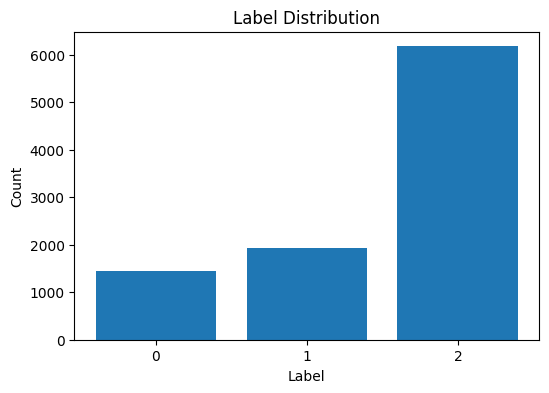

In [40]:
label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [41]:
train_df["TextLength"] = train_df['text'].astype(str).str.len()
train_df["WordCount"] = train_df['text'].astype(str).apply(lambda x:len(x.split()))
display(train_df[["TextLength","WordCount"]].describe())

display(train_df.groupby('LabelName')[["TextLength","WordCount"]].mean().round(2))

,TextLength,WordCount
count,9543.000000,9543.000000
mean,85.858325,12.178351
std,35.138568,4.665599
min,2.000000,1.000000
25%,58.000000,9.000000
50%,79.000000,11.000000
75%,120.000000,15.000000
max,190.000000,32.000000


,TextLength,WordCount
LabelName,,
Bearish,83.36,12.00
Bullish,80.45,11.93
Neutral,88.13,12.30


In [42]:
train_df

,text,label,LabelName,TextLength,WordCount
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,Bearish,77,10
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,Bearish,102,14
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,Bearish,94,14
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,Bearish,59,7
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,Bearish,71,10
...,...,...,...,...,...
9538,The Week's Gainers and Losers on the Stoxx Europe 50 --Dec. 2-6 #economy #MarketScreener https://t.co/iK5MO4NhQq https://t.co/AJh5V5fWTT,2,Neutral,136,16
9539,Tupperware Brands among consumer gainers; Unilever leads the losers,2,Neutral,67,9
9540,vTv Therapeutics leads healthcare gainers; Myomo and Biohaven Pharmaceutical among losers,2,Neutral,89,11
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral,47,9


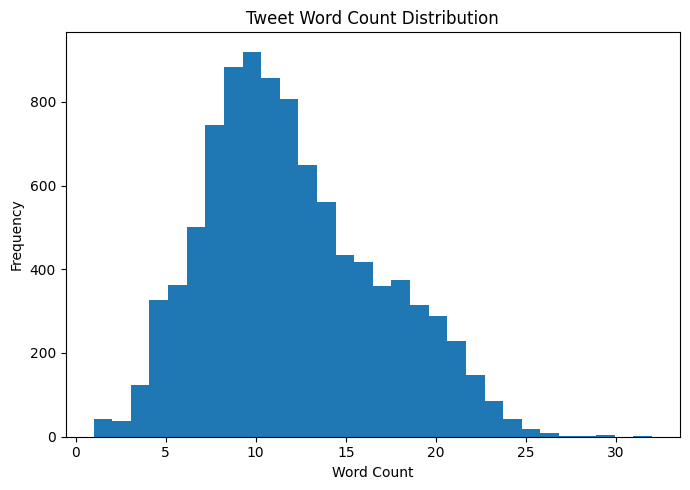

In [43]:
plt.figure(figsize=(7, 5))
train_df["WordCount"].plot(kind="hist", bins=30)
plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Data preprocessing

In [44]:
for df in [train_df, test_df]:
    df['CleanBasic'] = df['text'].apply(clean_text)
    df['CleanLemmatize'] = df['text'].apply(preprocess_lemma)
    df['CleanStmmer'] = df['text'].apply(preprocess_stem)
    df['TextLength'] = df['text'].astype(str).str.len()
    df['TextCount'] = df['text'].astype(str).apply(lambda x: len(str(x).split()))
display(train_df[['text','CleanBasic','CleanLemmatize','CleanStmmer']].head())

,text,CleanBasic,CleanLemmatize,CleanStmmer
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,bynd jpmorgan reels in expectations on beyond meat,bynd jpmorgan reel expectation meat,bynd jpmorgan reel expectation meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,ccl rcl nomura points to bookings weakness at carnival and royal caribbean,ccl rcl nomura point booking weakness carnival royal caribbean,ccl rcl nomura point booking weaknes carnival royal caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",cx cemex cut at credit suisse j p morgan on weak building outlook,cemex cut credit suisse morgan weak building outlook,cemex cut credit suisse morgan weak build outlook
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,ess btig research cuts to neutral,es btig research cut neutral,ess btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,fnko funko slides after piper jaffray pt cut,fnko funko slide piper jaffray cut,fnko funko slide piper jaffray cut


* Lemmatization is used for the final modeling text because it produces cleaner, more meaningful normalized tweets.

,word,frequency
0,stock,1341
1,market,571
2,marketscreener,480
3,new,417
4,report,403
5,price,394
6,say,393
7,result,382
8,earnings,352
9,share,343


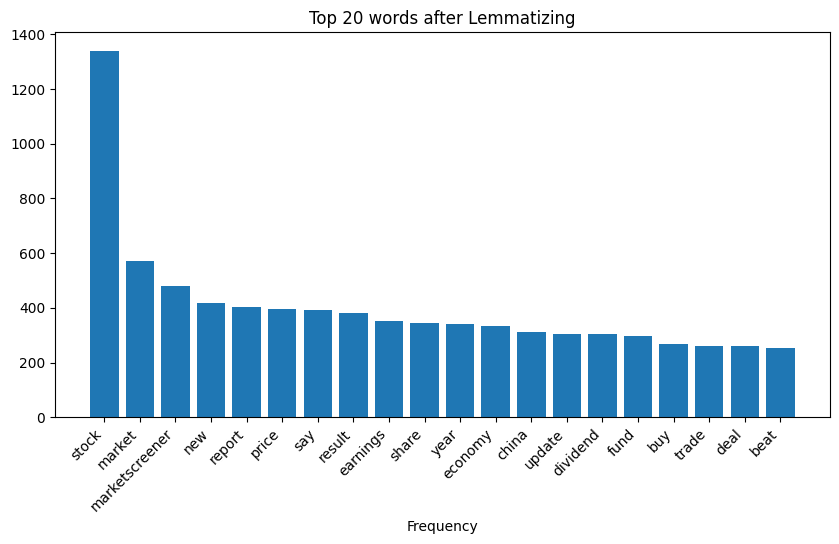

In [45]:

all_words = " ".join(train_df['CleanLemmatize'].fillna("")).split()
top_words = pd.DataFrame(Counter(all_words).most_common(20), columns=['word','frequency'])
display(top_words)
plt.figure(figsize=(10,5))
plt.bar(top_words['word'],top_words['frequency'])
plt.title("Top 20 words after Lemmatizing")
plt.xlabel("Word")
plt.xlabel("Frequency")
plt.xticks(rotation=45,ha='right')
plt.show()

In [46]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['CleanLemmatize'],
    train_df['label'],
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = train_df['label']
)

In [47]:
train_split = pd.DataFrame({
    "text" : train_df.loc[X_train.index,"text"] .values,
    "clean_text" : X_train.values,
    "label" : y_train.values,
})
val_split = pd.DataFrame({
    "text" : train_df.loc[X_val.index,"text"] .values,
    "clean_text" : X_val.values,
    "label" : y_val.values,
})

print("Total training split ",train_split.shape)
print("Total validation split ",val_split.shape)

# Training label distribution
print('Training label distribution :\n', train_split['label'].value_counts(normalize=True).round(3))
print("\n")
print('Validation label distribution :\n', val_split['label'].value_counts(normalize=True).round(3))

Total training split  (7634, 3)
Total validation split  (1909, 3)
Training label distribution :
 label
2    0.647
1    0.201
0    0.151
Name: proportion, dtype: float64


Validation label distribution :
 label
2    0.647
1    0.202
0    0.151
Name: proportion, dtype: float64


# Evaluation model

In [48]:
results = []
reports = {}
predictions = {}
def model_evaluation(name, model, X_trn=None, X_v=None, y_trn=None, y_v=None):
    if X_trn is None:
        X_trn, X_v, y_trn, y_v = X_train, X_val, y_train, y_val

    start = time.time()

    model.fit(X_trn, y_trn)
    pred = model.predict(X_v)

    end_time = time.time() - start

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="macro", zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="weighted", zero_division=0
    )

    accuracy = accuracy_score(y_v, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Total_evaluation_time": end_time
    })
    reports[name] = classification_report(y_v, pred,target_names=['Bearish','Bullish','Neutral'], zero_division=0)
    predictions[name] = pred
    print(f"{name}: accuracy={accuracy:.4f}, macro_f1={macro_f1:.4f},  weighted_f1={weighted_f1:.4f}, end_time={end_time:.2f} ")
    return model

# Final classification model: FinBERT

The testing notebook compared the candidate models and selected `Transformer: ProsusAI/finbert` as the best validation model. The following cells keep the same train/validation datasets created above and train only this final model.

In [49]:
RUN_TRANSFORMERS = True

MAX_TOKENS = 30000
MAX_SEQUENCE_LENGTH = 64
BATCH_SIZE = 32
TRANSFORMER_EPOCHS = 3
TRANSFORMER_MAX_LENGTH = 96

TRANSFORMER_ENCODERS = [
    "ProsusAI/finbert",
]

print("Train examples:", len(train_split))
print("Validation examples:", len(val_split))

Train examples: 7634
Validation examples: 1909


In [50]:
# Class weights help because this dataset is usually imbalanced.
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_split["label"].values
)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes, class_weight_values)}
CLASS_WEIGHTS

{0: 2.2050837666088965, 1: 1.6545296922410055, 2: 0.5149062457844328}

## FinBERT fine-tuning

This is the same Hugging Face `Trainer` approach used in the testing notebook, restricted to the selected final model only.

In [51]:
def run_transformer_encoder(model_name, train_split, val_split, epochs=3, max_length=96, batch_size=16):
    import time
    import numpy as np
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
    )

    set_global_seed(RANDOM_STATE)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = Dataset.from_pandas(
        train_split[["text", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False,
    )
    val_ds = Dataset.from_pandas(
        val_split[["text", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        metrics = evaluate_classification(labels, preds, model_name)
        return {
            "accuracy": metrics["Accuracy"],
            "macro_f1": metrics["Macro F1"],
            "weighted_f1": metrics["Weighted F1"],
            "macro_precision": metrics["Macro Precision"],
            "macro_recall": metrics["Macro Recall"],
        }

    training_kwargs = dict(
        output_dir=f"./transformer_runs/{model_name.replace('/', '_')}",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        seed=RANDOM_STATE,
    )

    try:
        training_args = TrainingArguments(eval_strategy="epoch", **training_kwargs)
    except TypeError:
        training_args = TrainingArguments(evaluation_strategy="epoch", **training_kwargs)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        #tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    pred_output = trainer.predict(val_ds)
    pred = np.argmax(pred_output.predictions, axis=1)
    elapsed = time.time() - start

    row = evaluate_classification(y_val, pred, f"Transformer: {model_name}", elapsed)
    report = classification_report(y_val, pred, target_names=LABEL_NAMES, zero_division=0)

    return {
        "model_name": model_name,
        "trainer": trainer,
        "tokenizer": tokenizer,
        "pred": pred,
        "row": row,
        "report": report,
    }

In [52]:
transformer_artifacts = {}
trained_models = {}

if RUN_TRANSFORMERS:
    try:
        encoder_name = TRANSFORMER_ENCODERS[0]
        print("" + "=" * 80)
        print("Fine-tuning:", encoder_name)

        artifact = run_transformer_encoder(
            encoder_name,
            train_split=train_split,
            val_split=val_split,
            epochs=TRANSFORMER_EPOCHS,
            max_length=TRANSFORMER_MAX_LENGTH,
            batch_size=16,
        )

        model_label = f"Transformer: {encoder_name}"
        transformer_artifacts[model_label] = artifact
        results.append(artifact["row"])
        reports[model_label] = artifact["report"]
        predictions[model_label] = artifact["pred"]
        trained_models[model_label] = artifact["trainer"]

        print(f"{model_label}: accuracy={artifact['row']['Accuracy']:.4f}, macro_f1={artifact['row']['Macro F1']:.4f}, weighted_f1={artifact['row']['Weighted F1']:.4f}")
        print(artifact["report"])

    except ImportError as e:
       print("Missing deep learning dependencies.")
       print("Install with: pip install torch transformers datasets accelerate evaluate")
       print(e)
else:
    print("RUN_TRANSFORMERS=False, skipping Transformer fine-tuning.")

Fine-tuning: ProsusAI/finbert


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21012.81it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.551924,0.397529,0.865898,0.810791,0.862652,0.835306,0.790884
2,0.283673,0.388247,0.870613,0.824876,0.870062,0.829542,0.820590
3,0.164470,0.486191,0.867470,0.825075,0.868216,0.819664,0.830843


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.56it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Transformer: ProsusAI/finbert: accuracy=0.8675, macro_f1=0.8251, weighted_f1=0.8682
              precision    recall  f1-score   support

     Bearish       0.74      0.78      0.76       288
     Bullish       0.80      0.81      0.80       385
     Neutral       0.92      0.91      0.91      1236

    accuracy                           0.87      1909
   macro avg       0.82      0.83      0.83      1909
weighted avg       0.87      0.87      0.87      1909



# Final validation results

In [53]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Model"], keep="last").sort_values("Macro F1", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("Best validation model:", best_model_name)
print("\nClassification report:")
print(reports[best_model_name])

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total_evaluation_time
0,Transformer: ProsusAI/finbert,0.86747,0.819664,0.830843,0.825075,0.868216,4189.492239


Best validation model: Transformer: ProsusAI/finbert

Classification report:
              precision    recall  f1-score   support

     Bearish       0.74      0.78      0.76       288
     Bullish       0.80      0.81      0.80       385
     Neutral       0.92      0.91      0.91      1236

    accuracy                           0.87      1909
   macro avg       0.82      0.83      0.83      1909
weighted avg       0.87      0.87      0.87      1909



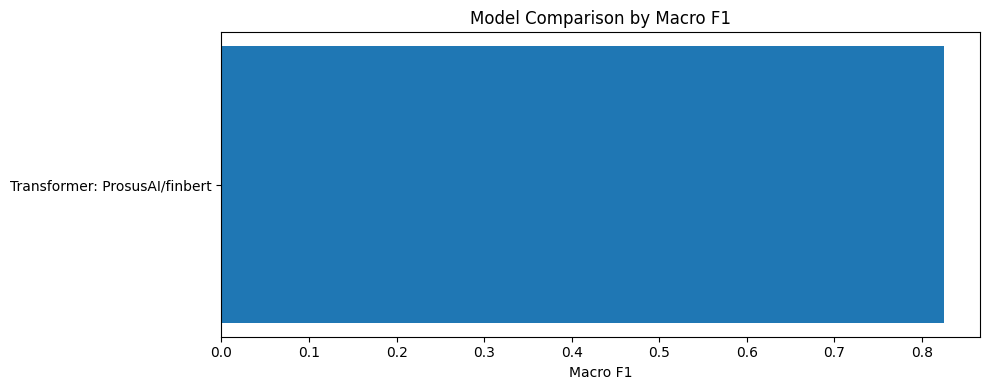

In [54]:
plt.figure(figsize=(10, max(4, 0.35 * len(results_df))))
plot_df = results_df.sort_values("Macro F1")
plt.barh(plot_df["Model"], plot_df["Macro F1"])
plt.title("Model Comparison by Macro F1")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

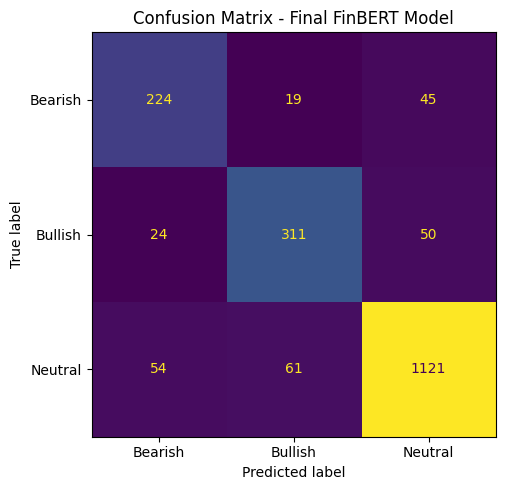

In [55]:
# Confusion matrix for the final validation model
cm = confusion_matrix(y_val, predictions[best_model_name], labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - Final FinBERT Model")
plt.tight_layout()
plt.show()

# Generate final predictions for Challenge 1

The trained FinBERT model is applied to the official `test.csv`. The output file `pred_15.csv` contains only the required columns: `id` and `label`.

In [56]:
from datasets import Dataset

final_artifact = transformer_artifacts[best_model_name]
final_trainer = final_artifact["trainer"]
final_tokenizer = final_artifact["tokenizer"]

test_ds = Dataset.from_pandas(
    test_df[["text"]].copy(),
    preserve_index=False,
)

def tokenize_test_batch(batch):
    return final_tokenizer(
        batch["text"],
        truncation=True,
        max_length=TRANSFORMER_MAX_LENGTH,
    )

test_ds = test_ds.map(tokenize_test_batch, batched=True)
test_pred_output = final_trainer.predict(test_ds)
test_predictions = np.argmax(test_pred_output.predictions, axis=1)

submission = make_submission(
    test_df["id"].values,
    test_predictions,
    output_path="pred_15.csv",
)

display(submission.head())
print("Saved: pred_15.csv")

Map: 100%|██████████| 2388/2388 [00:00<00:00, 19614.25 examples/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,id,label
0,0,1
1,1,2
2,2,2
3,3,0
4,4,2


Saved: pred_15.csv


In [57]:
results_df.to_csv("validation_results_15.csv", index=False)
print("Saved: validation_results_15.csv")

Saved: validation_results_15.csv
